# Compare All Passenger Counting Models
Aggregate per-model summaries, rank models, and generate full comparison charts.


In [1]:
# Cell 1 - Imports and helpers
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "ai_models" / "passenger_counting").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing ai_models/passenger_counting")


def pick_column(columns, candidates):
    column_set = set(columns)
    for name in candidates:
        if name in column_set:
            return name
    return None


PROJECT_ROOT = find_project_root(Path.cwd())
PASSENGER_ROOT = PROJECT_ROOT / "ai_models" / "passenger_counting"
RUN_ROOT = PASSENGER_ROOT / "runs" / "detect" / "separate_model_notebooks"
ARTIFACT_DIR = RUN_ROOT / "artifacts"
CHART_DIR = ARTIFACT_DIR / "comparison_charts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts:", ARTIFACT_DIR)


Artifacts: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts


In [2]:
# Cell 2 - Load model summaries
summary_files = sorted(ARTIFACT_DIR.glob("*_summary.json"))
rows = []
for path in summary_files:
    with open(path, "r", encoding="utf-8") as handle:
        rows.append(json.load(handle))

comparison_df = pd.DataFrame(rows)
if comparison_df.empty:
    print("No model summaries found yet. Run notebooks 01-04 first.")
else:
    comparison_df = comparison_df.sort_values(by=["Score", "mAP50-95", "mAP50"], ascending=False).reset_index(drop=True)
comparison_df


,Model,Model Key,Base Weight,Dataset YAML,Image Size,Epochs,Patience,Batch Preferred,Batch Fallback,Batch Used,...,Run Folder,Best Checkpoint,Copied Best Checkpoint,Results CSV,Best Epoch,Best Epoch mAP50-95,Last Epoch,Stopped Early,Proof Folder,Proof Files
0,YOLOv8s,yolov8s,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,640,150,20,16,8,16,...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\viva...,28,0.8246,48,True,C:\suttle project\smart-shuttle-ai-system\viva...,{'best.pt': 'C:\suttle project\smart-shuttle-a...
1,YOLO11s,yolo11s,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,640,150,20,16,8,16,...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\viva...,91,0.8227,111,True,C:\suttle project\smart-shuttle-ai-system\viva...,{'best.pt': 'C:\suttle project\smart-shuttle-a...
2,YOLOv10s,yolov10s,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,640,150,20,16,8,16,...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\viva...,79,0.8213,99,True,C:\suttle project\smart-shuttle-ai-system\viva...,{'best.pt': 'C:\suttle project\smart-shuttle-a...


In [3]:
# Cell 3 - Save ranking outputs
if comparison_df.empty:
    print("Skipping export: comparison_df is empty.")
    best_selection = {}
else:
    comparison_csv = ARTIFACT_DIR / "model_comparison_results.csv"
    comparison_json = ARTIFACT_DIR / "model_comparison_results.json"
    best_selection_json = ARTIFACT_DIR / "best_model_selection.json"

    comparison_df.to_csv(comparison_csv, index=False)
    with open(comparison_json, "w", encoding="utf-8") as handle:
        json.dump({"rows": comparison_df.to_dict(orient="records")}, handle, indent=2)

    best_row = comparison_df.iloc[0].to_dict()
    best_selection = {
        "best_model_name": best_row["Model"],
        "best_model_key": best_row["Model Key"],
        "best_base_weight": best_row["Base Weight"],
        "best_score": best_row["Score"],
        "best_mAP50_95": best_row["mAP50-95"],
        "best_epoch": best_row.get("Best Epoch"),
        "best_checkpoint": best_row["Best Checkpoint"],
        "comparison_csv": str(comparison_csv),
        "comparison_json": str(comparison_json),
    }
    with open(best_selection_json, "w", encoding="utf-8") as handle:
        json.dump(best_selection, handle, indent=2)

    print("Saved:", comparison_csv)
    print("Saved:", comparison_json)
    print("Saved:", best_selection_json)

best_selection


Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\model_comparison_results.csv
Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\model_comparison_results.json
Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\best_model_selection.json


{'best_model_name': 'YOLOv8s',
 'best_model_key': 'yolov8s',
 'best_base_weight': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\yolov8s.pt',
 'best_score': 0.8909,
 'best_mAP50_95': 0.8271,
 'best_epoch': 28,
 'best_checkpoint': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\runs\\detect\\separate_model_notebooks\\YOLOv8s\\weights\\best.pt',
 'comparison_csv': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\runs\\detect\\separate_model_notebooks\\artifacts\\model_comparison_results.csv',
 'comparison_json': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\runs\\detect\\separate_model_notebooks\\artifacts\\model_comparison_results.json'}

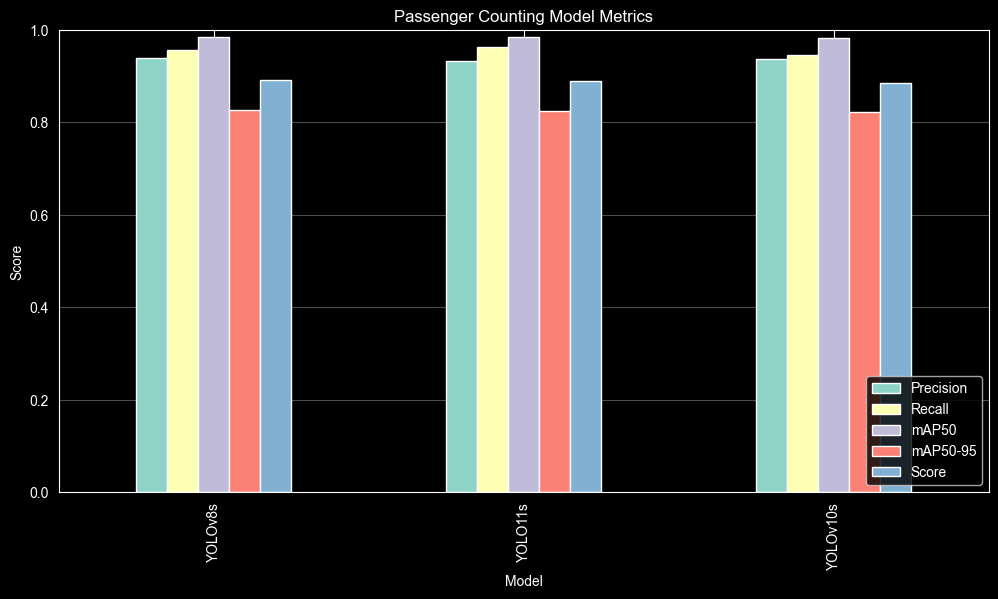

Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\comparison_charts\metrics_grouped_bar.png


In [4]:
# Cell 4 - Grouped metrics chart
if comparison_df.empty:
    print("Skipping chart: no data.")
else:
    chart_cols = ["Precision", "Recall", "mAP50", "mAP50-95", "Score"]
    chart_df = comparison_df[["Model", *chart_cols]].set_index("Model")
    ax = chart_df.plot(kind="bar", figsize=(12, 6))
    ax.set_title("Passenger Counting Model Metrics")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="lower right")
    grouped_bar_path = CHART_DIR / "metrics_grouped_bar.png"
    plt.savefig(grouped_bar_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", grouped_bar_path)


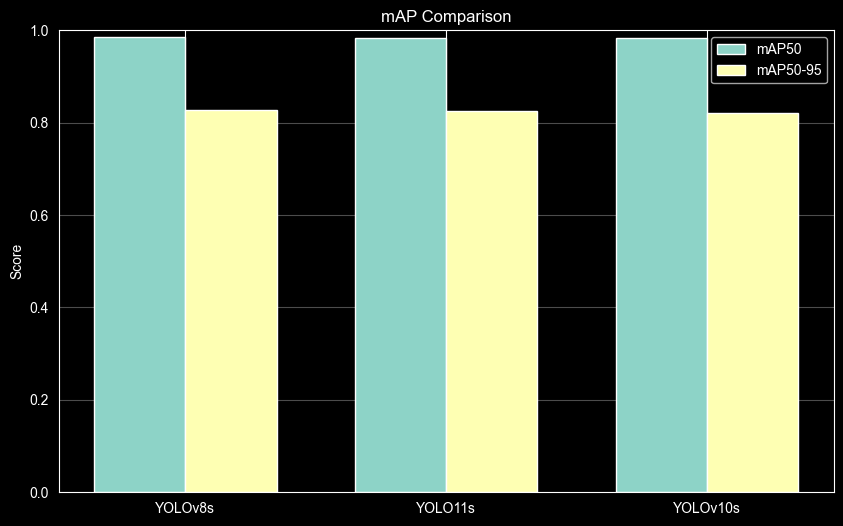

Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\comparison_charts\map_comparison.png


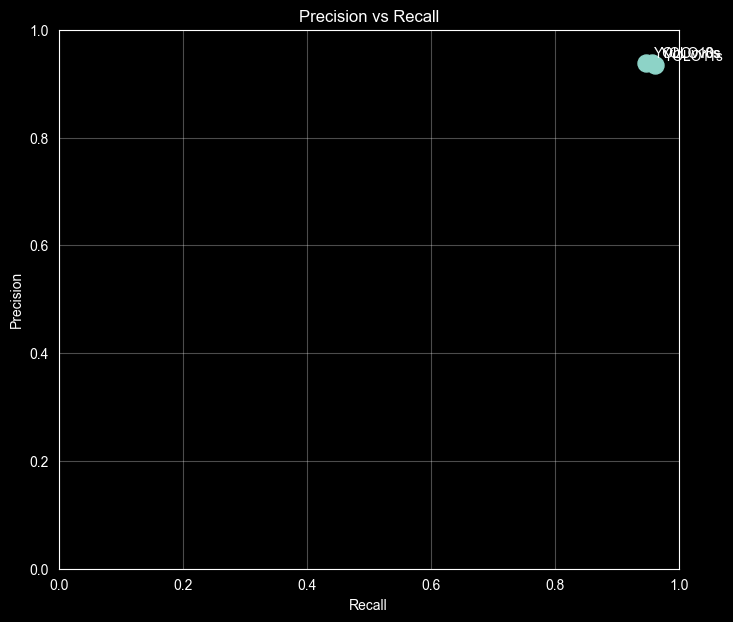

Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\comparison_charts\precision_recall_scatter.png


In [5]:
# Cell 5 - mAP comparison + precision/recall scatter
if comparison_df.empty:
    print("Skipping charts: no data.")
else:
    plt.figure(figsize=(10, 6))
    width = 0.35
    x = list(range(len(comparison_df)))
    plt.bar([i - width / 2 for i in x], comparison_df["mAP50"], width=width, label="mAP50")
    plt.bar([i + width / 2 for i in x], comparison_df["mAP50-95"], width=width, label="mAP50-95")
    plt.xticks(x, comparison_df["Model"])
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("mAP Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    map_path = CHART_DIR / "map_comparison.png"
    plt.savefig(map_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", map_path)

    plt.figure(figsize=(8, 7))
    plt.scatter(comparison_df["Recall"], comparison_df["Precision"], s=150)
    for _, row in comparison_df.iterrows():
        plt.annotate(row["Model"], (row["Recall"], row["Precision"]), xytext=(6, 4), textcoords="offset points")
    plt.xlim(0, 1.0)
    plt.ylim(0, 1.0)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.grid(alpha=0.3)
    pr_path = CHART_DIR / "precision_recall_scatter.png"
    plt.savefig(pr_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", pr_path)


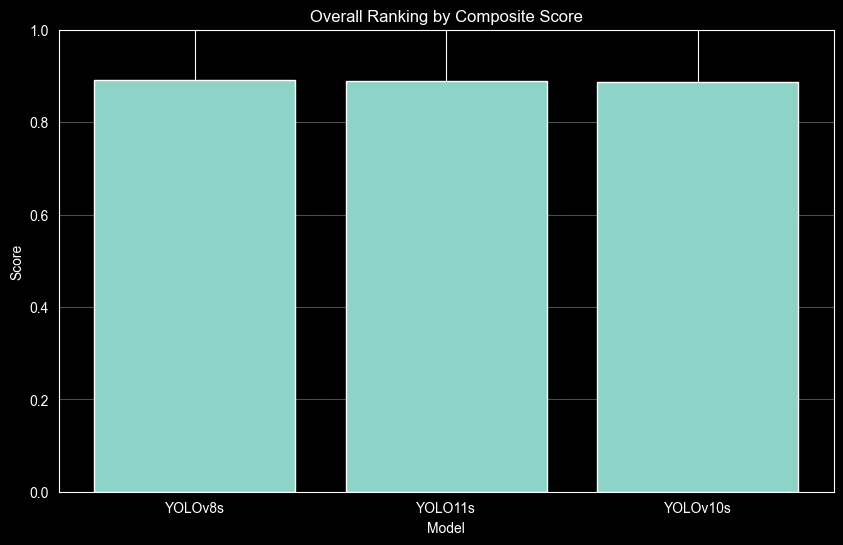

Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\comparison_charts\ranking_score.png


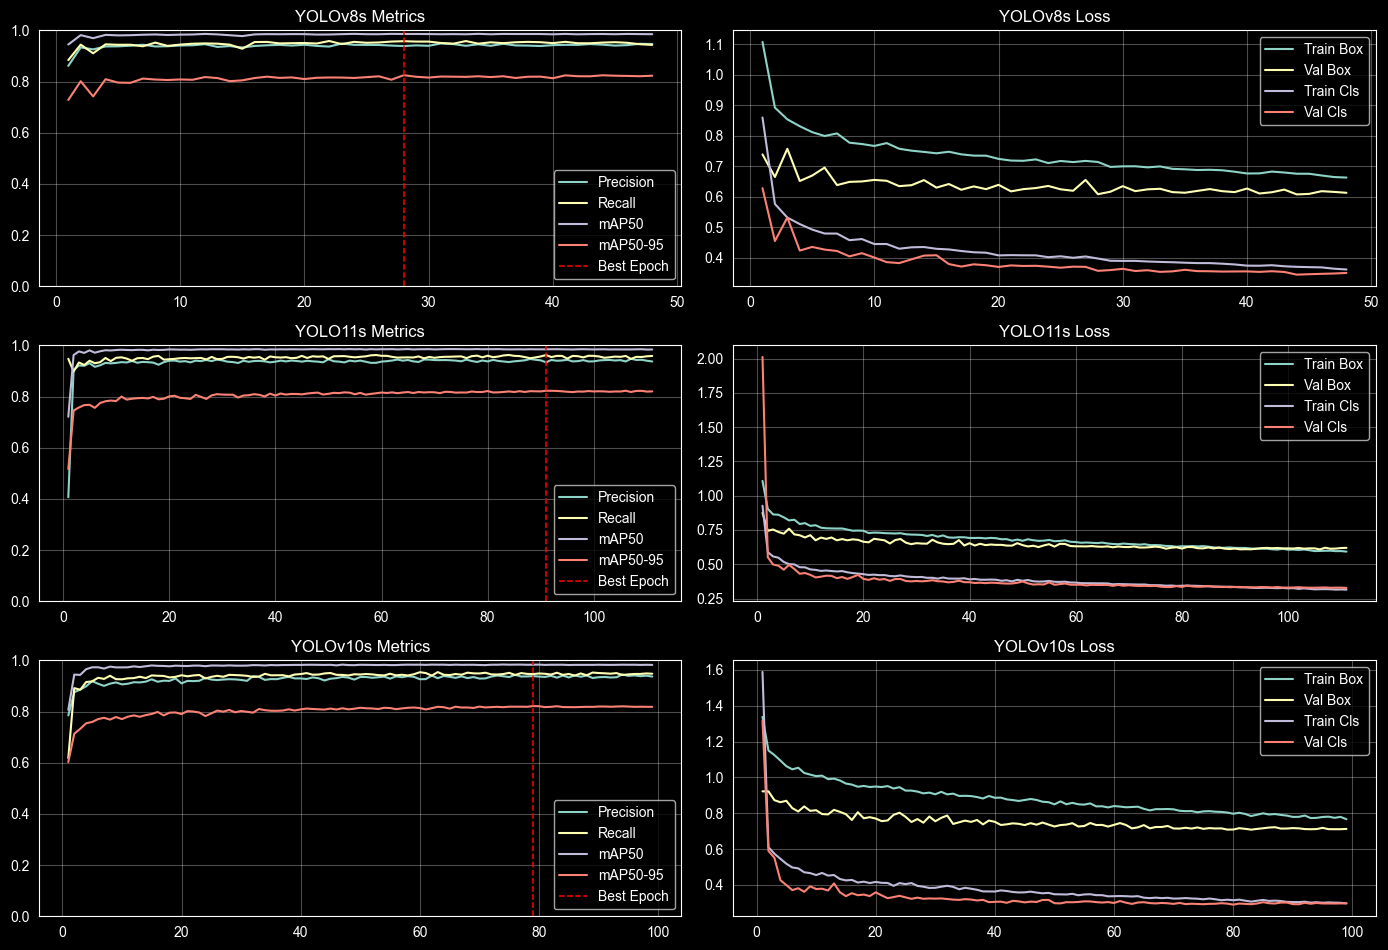

Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\comparison_charts\training_curves_grid.png


In [6]:
# Cell 6 - Ranking chart + per-model training curve grid
if comparison_df.empty:
    print("Skipping charts: no data.")
else:
    plt.figure(figsize=(10, 6))
    plt.bar(comparison_df["Model"], comparison_df["Score"])
    plt.ylim(0, 1.0)
    plt.title("Overall Ranking by Composite Score")
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.grid(axis="y", alpha=0.3)
    rank_path = CHART_DIR / "ranking_score.png"
    plt.savefig(rank_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", rank_path)

    rows = len(comparison_df)
    fig, axes = plt.subplots(rows, 2, figsize=(14, max(4, rows * 3.2)))
    if rows == 1:
        axes = [axes]

    for idx, (_, row) in enumerate(comparison_df.iterrows()):
        ax_metrics = axes[idx][0]
        ax_loss = axes[idx][1]

        csv_path = Path(row.get("Results CSV", ""))
        if not csv_path.exists():
            ax_metrics.text(0.5, 0.5, f"Missing results.csv: {row['Model']}", ha="center", va="center")
            ax_loss.text(0.5, 0.5, f"Missing results.csv: {row['Model']}", ha="center", va="center")
            continue

        df_csv = pd.read_csv(csv_path)
        df_csv.columns = [str(c).strip() for c in df_csv.columns]
        epoch_col = pick_column(df_csv.columns, ["epoch", "Epoch"]) or df_csv.columns[0]

        metric_any = False
        for label, candidates in [
            ("Precision", ["metrics/precision(B)", "metrics/precision"]),
            ("Recall", ["metrics/recall(B)", "metrics/recall"]),
            ("mAP50", ["metrics/mAP50(B)", "metrics/mAP50"]),
            ("mAP50-95", ["metrics/mAP50-95(B)", "metrics/mAP50-95"]),
        ]:
            col = pick_column(df_csv.columns, candidates)
            if col:
                ax_metrics.plot(df_csv[epoch_col], df_csv[col], label=label)
                metric_any = True

        best_epoch = row.get("Best Epoch")
        if pd.notna(best_epoch):
            ax_metrics.axvline(int(best_epoch), color="red", linestyle="--", linewidth=1.1, label="Best Epoch")

        ax_metrics.set_title(f"{row['Model']} Metrics")
        ax_metrics.set_ylim(0, 1.0)
        ax_metrics.grid(alpha=0.3)
        if metric_any:
            ax_metrics.legend(loc="lower right")

        loss_any = False
        for label, candidates in [
            ("Train Box", ["train/box_loss"]),
            ("Val Box", ["val/box_loss"]),
            ("Train Cls", ["train/cls_loss"]),
            ("Val Cls", ["val/cls_loss"]),
        ]:
            col = pick_column(df_csv.columns, candidates)
            if col:
                ax_loss.plot(df_csv[epoch_col], df_csv[col], label=label)
                loss_any = True

        ax_loss.set_title(f"{row['Model']} Loss")
        ax_loss.grid(alpha=0.3)
        if loss_any:
            ax_loss.legend(loc="upper right")

    plt.tight_layout()
    grid_path = CHART_DIR / "training_curves_grid.png"
    plt.savefig(grid_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", grid_path)


In [7]:
# Cell 7 - Final summary
if not best_selection:
    print("No best model yet. Run notebooks 01-04 and then rerun this notebook.")
else:
    print("Best model:", best_selection["best_model_name"])
    print("Best score:", best_selection["best_score"])
    print("Best mAP50-95:", best_selection["best_mAP50_95"])
    print("Best epoch:", best_selection.get("best_epoch"))
    print("Best checkpoint:", best_selection["best_checkpoint"])


Best model: YOLOv8s
Best score: 0.8909
Best mAP50-95: 0.8271
Best epoch: 28
Best checkpoint: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\YOLOv8s\weights\best.pt


## Viva Comparison Method
- All models are compared using the same dataset and same core settings (`imgsz=640`, `epochs=150`, `patience=20`, same batch strategy, same `device=0`).
- For each model, `results.csv` is read from `viva_model_comparison_proof/<model>/results.csv`.
- Best model selection rule: highest **best mAP50-95**; tie-breaker is higher **best mAP50**.


In [8]:
# Cell 8 - Viva-proof comparison from results.csv
VIVA_PROOF_ROOT = PROJECT_ROOT / "viva_model_comparison_proof"
MODEL_DIRS = {
    "yolov8s": VIVA_PROOF_ROOT / "yolov8s",
    "yolov10s": VIVA_PROOF_ROOT / "yolov10s",
    "yolo11s": VIVA_PROOF_ROOT / "yolo11s",
    "rtdetr_l": VIVA_PROOF_ROOT / "rtdetr_l",
}
MODEL_NAMES = {
    "yolov8s": "YOLOv8s",
    "yolov10s": "YOLOv10s",
    "yolo11s": "YOLO11s",
    "rtdetr_l": "RTDETR-L",
}

rows = []
missing_csv_files = []

for model_key, model_dir in MODEL_DIRS.items():
    csv_path = model_dir / "results.csv"
    if not csv_path.exists():
        missing_csv_files.append(str(csv_path))
        continue

    df = pd.read_csv(csv_path)
    if df.empty:
        print(f"Skipping {model_key}: results.csv is empty.")
        continue

    df.columns = [str(c).strip() for c in df.columns]
    epoch_col = pick_column(df.columns, ["epoch", "Epoch"]) or df.columns[0]
    map50_col = pick_column(df.columns, ["metrics/mAP50(B)", "metrics/mAP50"])
    map5095_col = pick_column(df.columns, ["metrics/mAP50-95(B)", "metrics/mAP50-95"])

    if map50_col is None or map5095_col is None:
        print(f"Skipping {model_key}: required mAP columns not found in {csv_path}.")
        continue

    best_idx_map5095 = int(df[map5095_col].idxmax())
    best_idx_map50 = int(df[map50_col].idxmax())

    best_epoch_map5095 = int(df.loc[best_idx_map5095, epoch_col]) if epoch_col else best_idx_map5095
    best_epoch_map50 = int(df.loc[best_idx_map50, epoch_col]) if epoch_col else best_idx_map50

    rows.append(
        {
            "Model Key": model_key,
            "Model": MODEL_NAMES.get(model_key, model_key),
            "Results CSV": str(csv_path),
            "Best mAP50": float(df.loc[best_idx_map50, map50_col]),
            "Best mAP50 Epoch": best_epoch_map50,
            "Best mAP50-95": float(df.loc[best_idx_map5095, map5095_col]),
            "Best mAP50-95 Epoch": best_epoch_map5095,
        }
    )

comparison_viva_df = pd.DataFrame(rows)
if not comparison_viva_df.empty:
    comparison_viva_df = comparison_viva_df.sort_values(
        by=["Best mAP50-95", "Best mAP50"],
        ascending=False,
    ).reset_index(drop=True)

print("Viva proof root:", VIVA_PROOF_ROOT)
if missing_csv_files:
    print("Missing results.csv files:")
    for item in missing_csv_files:
        print("-", item)

comparison_viva_df


Viva proof root: C:\suttle project\smart-shuttle-ai-system\viva_model_comparison_proof
Missing results.csv files:
- C:\suttle project\smart-shuttle-ai-system\viva_model_comparison_proof\rtdetr_l\results.csv


,Model Key,Model,Results CSV,Best mAP50,Best mAP50 Epoch,Best mAP50-95,Best mAP50-95 Epoch
0,yolov8s,YOLOv8s,C:\suttle project\smart-shuttle-ai-system\viva...,0.98621,34,0.82460,28
1,yolo11s,YOLO11s,C:\suttle project\smart-shuttle-ai-system\viva...,0.98548,65,0.82266,91
2,yolov10s,YOLOv10s,C:\suttle project\smart-shuttle-ai-system\viva...,0.98365,74,0.82133,79


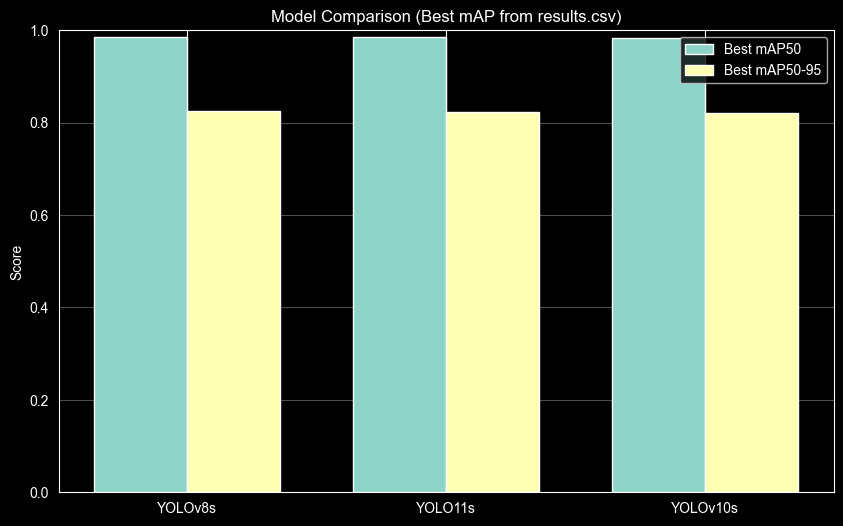

Saved: C:\suttle project\smart-shuttle-ai-system\viva_model_comparison_proof\comparison_results.csv
Saved: C:\suttle project\smart-shuttle-ai-system\viva_model_comparison_proof\comparison_chart.png
Saved: C:\suttle project\smart-shuttle-ai-system\viva_model_comparison_proof\viva_summary.txt
Final selected best model: YOLOv8s


{'best_model': 'YOLOv8s',
 'best_model_key': 'yolov8s',
 'best_mAP50-95': 0.8246,
 'best_mAP50-95_epoch': 28,
 'best_mAP50': 0.98621,
 'best_mAP50_epoch': 34,
 'comparison_csv': 'C:\\suttle project\\smart-shuttle-ai-system\\viva_model_comparison_proof\\comparison_results.csv',
 'comparison_chart': 'C:\\suttle project\\smart-shuttle-ai-system\\viva_model_comparison_proof\\comparison_chart.png'}

In [9]:
# Cell 9 - Save viva comparison outputs
if comparison_viva_df.empty:
    print("No comparison data found. Run notebooks 01-04 first.")
    final_best_model = {}
else:
    VIVA_PROOF_ROOT.mkdir(parents=True, exist_ok=True)
    comparison_csv_path = VIVA_PROOF_ROOT / "comparison_results.csv"
    comparison_chart_path = VIVA_PROOF_ROOT / "comparison_chart.png"
    viva_summary_path = VIVA_PROOF_ROOT / "viva_summary.txt"

    comparison_viva_df.to_csv(comparison_csv_path, index=False)

    plt.figure(figsize=(10, 6))
    x = range(len(comparison_viva_df))
    width = 0.36
    plt.bar([i - width / 2 for i in x], comparison_viva_df["Best mAP50"], width=width, label="Best mAP50")
    plt.bar([i + width / 2 for i in x], comparison_viva_df["Best mAP50-95"], width=width, label="Best mAP50-95")
    plt.xticks(list(x), comparison_viva_df["Model"])
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Model Comparison (Best mAP from results.csv)")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.savefig(comparison_chart_path, dpi=220, bbox_inches="tight")
    plt.show()

    best_row = comparison_viva_df.iloc[0].to_dict()
    final_best_model = {
        "best_model": best_row["Model"],
        "best_model_key": best_row["Model Key"],
        "best_mAP50-95": best_row["Best mAP50-95"],
        "best_mAP50-95_epoch": int(best_row["Best mAP50-95 Epoch"]),
        "best_mAP50": best_row["Best mAP50"],
        "best_mAP50_epoch": int(best_row["Best mAP50 Epoch"]),
        "comparison_csv": str(comparison_csv_path),
        "comparison_chart": str(comparison_chart_path),
    }

    summary_lines = [
        "Smart Shuttle AI - Viva Model Comparison Summary",
        "",
        "Fairness settings used across all models:",
        "- Same dataset: ai_models/passenger_counting/datasets/smart_bus_final/data.yaml",
        "- Same image size: 640",
        "- Same epochs: 150",
        "- Same early stopping patience: 20",
        "- Same device: CUDA GPU (device=0)",
        "- Same batch strategy: 16, fallback to 8 only on CUDA out-of-memory",
        "",
        "Best model selection method:",
        "- Primary: highest Best mAP50-95 from each model's results.csv",
        "- Tie-breaker: highest Best mAP50",
        "",
        f"Selected best model: {final_best_model['best_model']}",
        f"Best mAP50-95: {final_best_model['best_mAP50-95']:.4f} at epoch {final_best_model['best_mAP50-95_epoch']}",
        f"Best mAP50: {final_best_model['best_mAP50']:.4f} at epoch {final_best_model['best_mAP50_epoch']}",
        "",
        f"Comparison CSV: {comparison_csv_path}",
        f"Comparison chart: {comparison_chart_path}",
    ]
    viva_summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

    print("Saved:", comparison_csv_path)
    print("Saved:", comparison_chart_path)
    print("Saved:", viva_summary_path)
    print("Final selected best model:", final_best_model["best_model"])

final_best_model
